# Function minimization, and analysis of diet results

## Introduction

Halfway through last year (2025), I decided (at long last) to get serious about shedding weight.

I was eating healthy food, just too much of it.  In order to keep motivated, I collected my daily weighin data, and produced a plot each day, predicting when my target weight would be achieved.  I actually had two targets weights:  80 kilogram (kg) - a nice round number, and 78 kg (chosen after I got to 80 kg, and found my BMI __still__ wasn't in the green zone).

I achieved my stretch goal on the morning on Christmas Day.  Of course, my diet went out the window during the Christmas Day feast, but I am clawing back to 78 kg as I write these words

I found that the analysis of my diet's progress can be done in two different ways, each  telling a different story, one more nuanced than the other.

------------------------

## Implementation

### Imports

Import packages used

- pathlib for file name management
- pandas for DataFrame management
- plotnine for plotting (my go-to package)
- scipy for function minimization
- statsmodels for fitting a linear model to the data

In [1]:
import pathlib

import numpy as np
import pandas as pd
import plotnine as p9
import scipy
import statsmodels.api as sm
from statsmodels.formula.api import ols

__watermark__ provides reproducability information

In [2]:
%load_ext watermark

## Data load

We read our data from an Excel spreadsheet, specifying:

- the sheet in the spreadsheet we want
- the columns to use
- the initial rows to skip
- the number of rows to read in
- the names to use for the columns

In [3]:
path = pathlib.Path("diet_results.xlsx")
df = pd.read_excel(
    path,
    sheet_name="Data Entry",
    usecols=[3, 4],
    skiprows=2,
    nrows=141,
    names=["day", "weight"],
)

We examine the first and last few rows, and check the datatypes of the columns (all OK)

In [4]:
df.head()

,day,weight
0,1,83.8
1,2,84.2
2,3,83.7
3,4,84.5
4,5,83.5


In [5]:
df.tail()

,day,weight
136,173,78.6
137,174,78.5
138,175,78.3
139,176,78.2
140,177,78.0


In [6]:
df.dtypes

day         int64
weight    float64
dtype: object

----------------------
## Data visualization

We use __plotnine__ for our plotting.

We :
-  create an empty plot, specifying the default source of data for subsequent plotting operations
-  create a layer with points, with x, y values take from our source DataFrame
-  create a layer with one point, from the last row of the DataFrame, and  show as a red point
-  use a black-and-white theme to miminize chart clutter
-  draw a horizontal line to show the final target weight
-  draw a vertical line to show when the diet stated (day 0)
-  add a plot subtitle, and caption

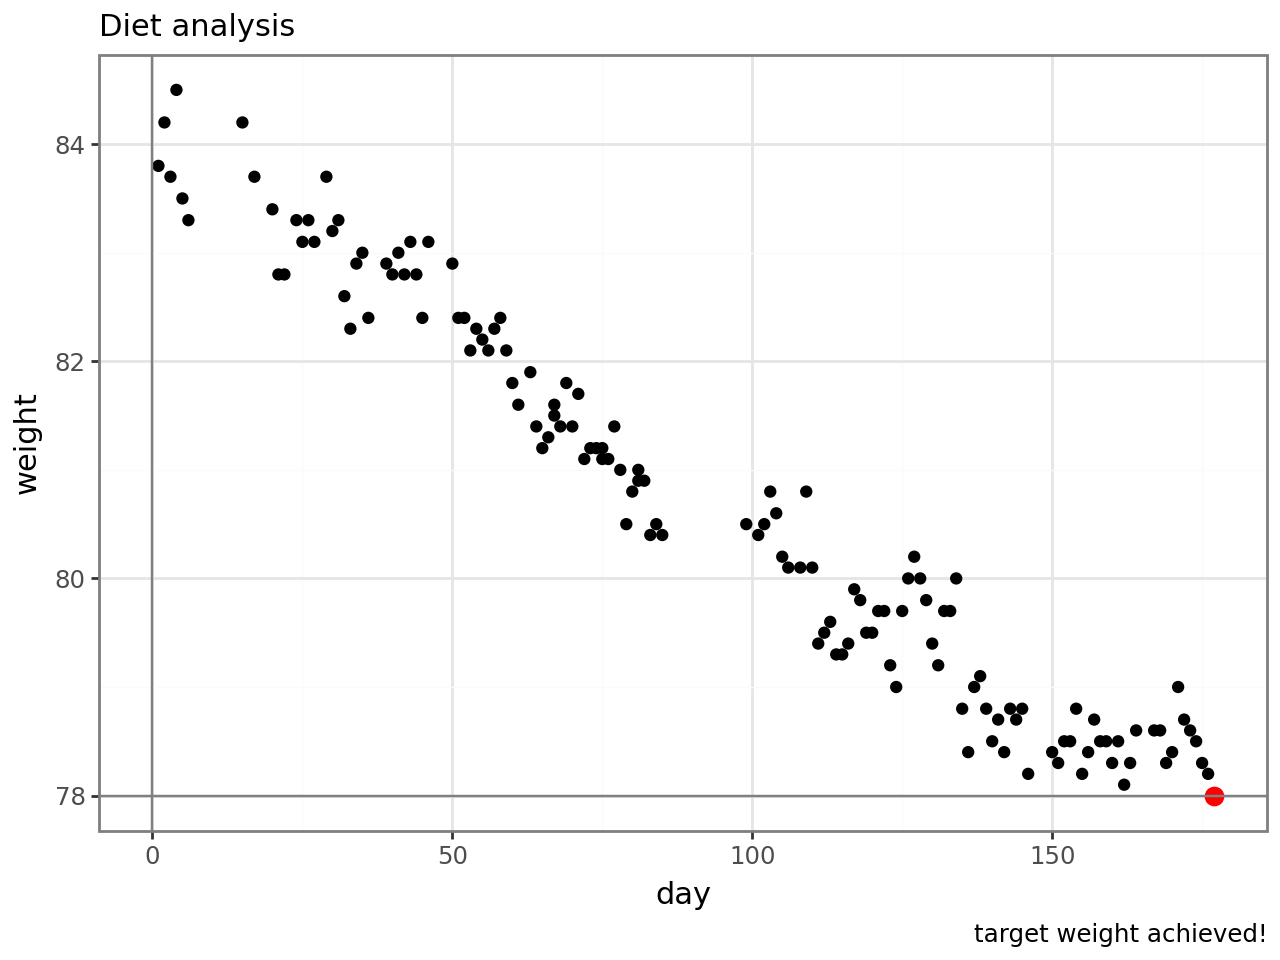

In [7]:
plot = (
    p9.ggplot(
        data=df,
    )
    + p9.geom_point(
        mapping=p9.aes(x="day", y="weight"),
    )
    + p9.geom_point(
        data=df.tail(1),
        mapping=p9.aes(x="day", y="weight"),
        color="red",
        size=3,
    )
    + p9.theme_bw()
    + p9.geom_hline(
        mapping=p9.aes(yintercept=78),
        color="gray",
    )
    + p9.geom_vline(
        mapping=p9.aes(xintercept=0),
        color="gray",
    )
    + p9.labs(subtitle="Diet analysis", caption="target weight achieved!")
)
plot

## Plot enhancements

One of the nice features of __plotnine__ is that you can add addition layers to the initial graphic.

In the next plot, we add a layer showing linear model (constant weight loss each day), with the 95% confidence area shaded grey.  The model is matched the data by Ordinary Least Squares (__ols__)

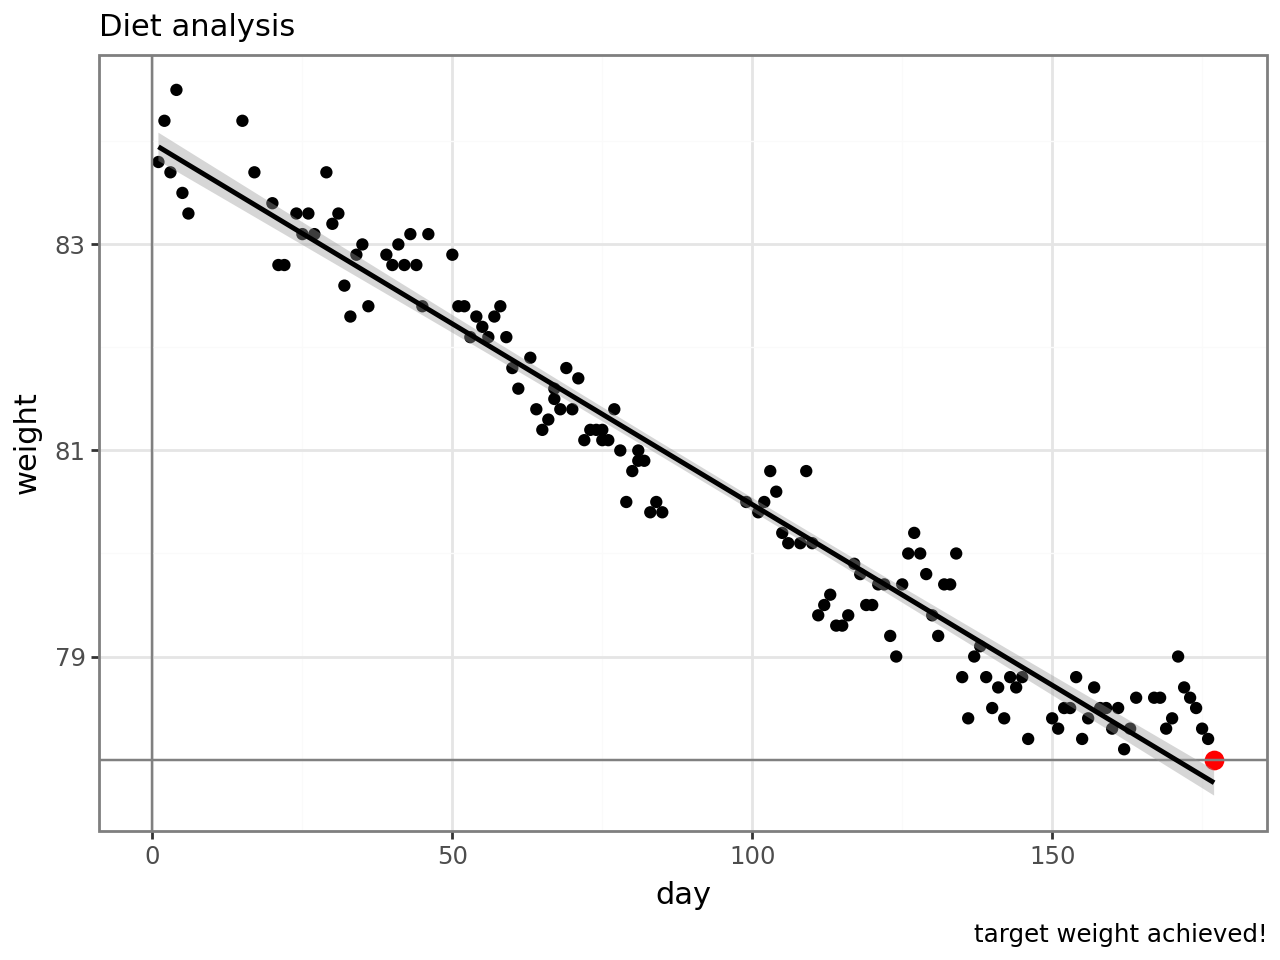

In [8]:
plot = plot + p9.geom_smooth(mapping=p9.aes(x="day", y="weight"), method="ols", se=0.95)
plot

This tells an impressive story of constant improvment each day.  A story of steady progress towards the target.  To these skeptical people want statistical proof, we run the __statsmodel__ __ols__ routine, to get the p-values for each coefficient, and the overall R^2 value.  We invert the weight loss per day to give "days to lose 1 kg": a more understandable concept than "grams lost each day".

In [9]:
res1 = ols("weight ~ day", data=df).fit()

# create a summary of the OLS fit to go on the plot
equation = (
    f'weight = {res1.params["Intercept"]:.1f} - day / {1/abs(res1.params["day"]):.1f}\n\n'
    + f"R^2 = {res1.rsquared:.2f}"
)

Show the statistical summary

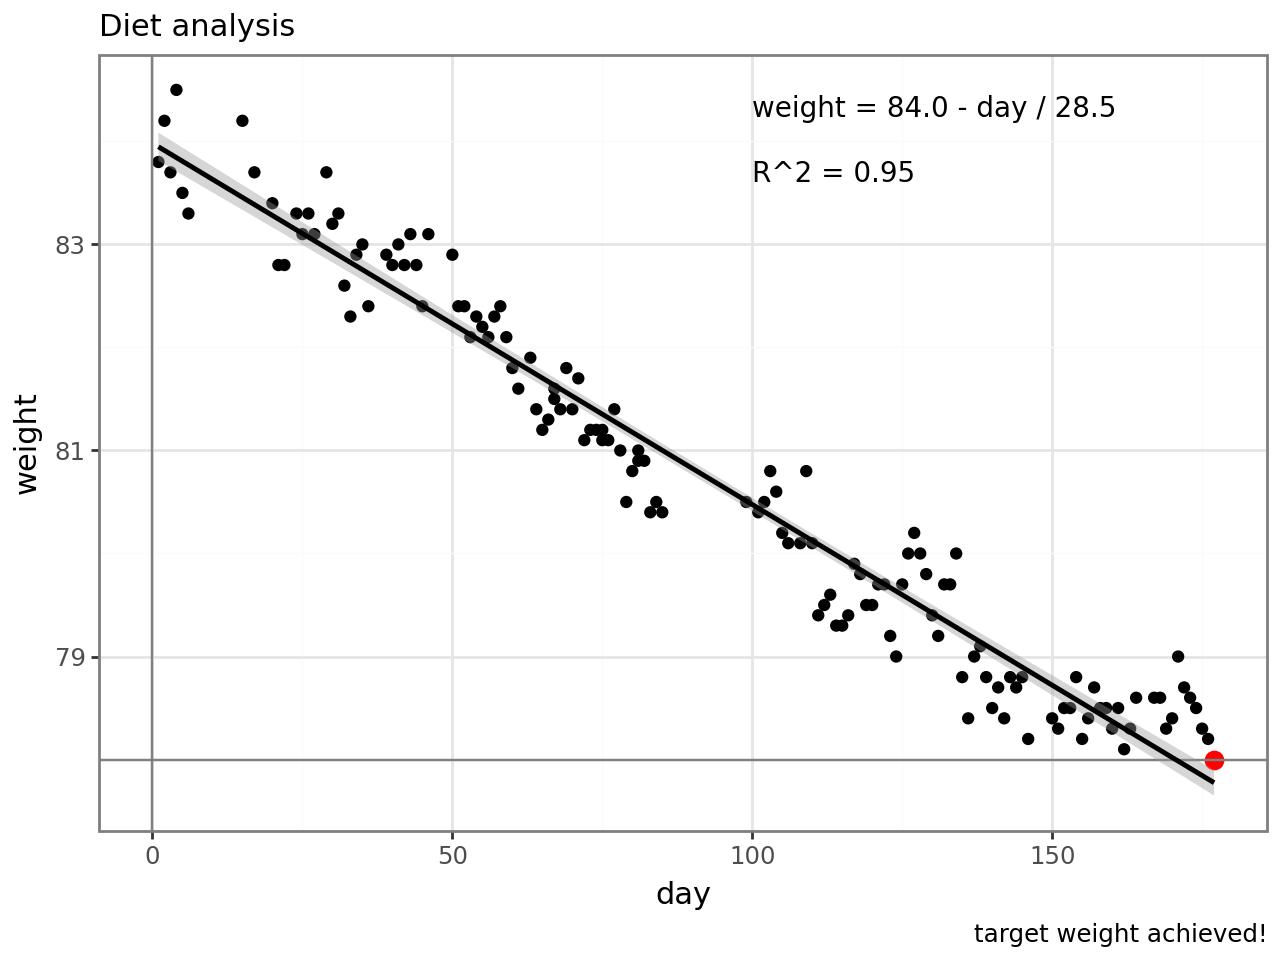

In [10]:
plot = plot + p9.annotate(
    "text",
    x=100,
    y=84,
    label=equation,
    size=10,
    ha="left",
)
plot

-----------------------

## A more nuanced model

I know that my motivation flagged in the run up to Christmas, and my dieting wasn't as strict as initially efforts.

So I decided to fit a more complex model.  One with a steady linear decrease in weight, until a breakpoint was reached, and then no weight loss after that point.

I used the __scipy.optimize.differential_evolution__ function.

       
    The differential evolution method [1] is stochastic in nature. It does not use gradient methods to find the minimum, and can search large areas of candidate space, but often requires larger numbers of function evaluations than conventional gradient-based techniques.

I developed a function that took a set of parameters that characterised my model (y intercept, initial slope, and breakpoint after which slope=0), and computed the sum of squares of the deviation between model and actual data.  You tell the __scipy.optimize.differential_evolution__ function the range of each parameter, and it finds the parameter set that minimizes the sum-of-square-errors value (computed by the __my_sq_error__ function.

Get the __day__ and __weight__ arrays into more conventional terms (x, y), as global arrays.

In [11]:
x = df["day"]
y = df["weight"]

The parameters set is (initial slope, y intercept , x breakpoint ).  We define a function that takes this parameter set, and computes the sum of squared errors,  model versus true data.

In [12]:
def my_sq_error(a):
    """
    my_sq_error: compute sum of square errors, model vs data

    Parameters: a - an array of model parameters

    We expect a to be an array 3 long, and we interpret the parameters as:
    a1 - initial slope (weight loss per day)
    a2 - initial weight
    a3 - day at which the daily weight loss was 0

    For each x value, we compute the model prediction, and square the error with
    the measured value.
    Finally, we sum all square error values

    We expect this function to be called by the function minimization utility
    """
    a1 = a[0]
    a2 = a[1]
    a3 = a[2]

    # value of estimated y at breakpoint x (= a3)
    a4 = a1 * a3 + a2

    sq_error = []
    for x_i, y_i in zip(x, y):
        y_est = a4 if x_i >= a3 else (a1 * x_i + a2)
        sq_error.append((y_est - y_i) ** 2)
    # end for
    return sum(sq_error)


# end my_sq_error

Specify the allowed range for each parameter  (I have selected very generous ranges).  This also tells the minimization utility how many parameters are in our model.

In [13]:
# input vector to D_E is [slope range, y intercept range, x breakpoint range]
slope_range = (-1.0, 1.0)  # says slope can be lossing a kg a day to gaining a kg a day!
yintercept_range = (50, 100)  # initial weight can vary from 50kg to 100kg
xbreakpoint_range = (
    100,
    200,
)  # the range of the day value after which no weight loss occurs
bounds = [slope_range, yintercept_range, xbreakpoint_range]

-----------------
## Run the minimization

In [14]:
result1 = scipy.optimize.differential_evolution(
    my_sq_error,
    bounds=bounds,
)

Get the new equation for weight loss

In [15]:
slope = result1["x"][0]
initial = result1["x"][1]
xbreakpoint = result1["x"][2]

In [16]:
equation = f"weight = {initial:.1f} - days / {(1/abs(slope)):.1f}"
equation

'weight = 84.1 - days / 26.6'

Compute the predictions of our optimized model with final parameter set, and construct a new DataFrame

In [17]:
a1 = result1["x"][0]  # weight loss per day
a2 = result1["x"][1]  # initial weight
a3 = result1["x"][2]  # breakpoint day, after which no weight loss


a4 = a1 * a3 + a2  # predicted weight at breakpoint day

y_est = [a4 if x_i > a3 else (a1 * x_i + a2) for x_i in x]

df = pd.DataFrame({"x": x, "y": y, "y_est": y_est})

-----------------------

## Visualize results

We:
-  create and empty plot, and specify our data source
-  create a layer with data points
-  create a layer with a vertical line at day=0
-  create a layer with a horizontal line at target weight
-  create a layer with a single point at the end of the weight loss line, larger, and colored tan
-  specify a black-and=white theme to minimize chart junk
-  create a layer with a line showing our model predictions
-  create a legend that explains the colors on the plot
-  label the x, y axis, and set the subtitle
-  show the model equation
-  resize the plot, now we have a legend taking up space to right

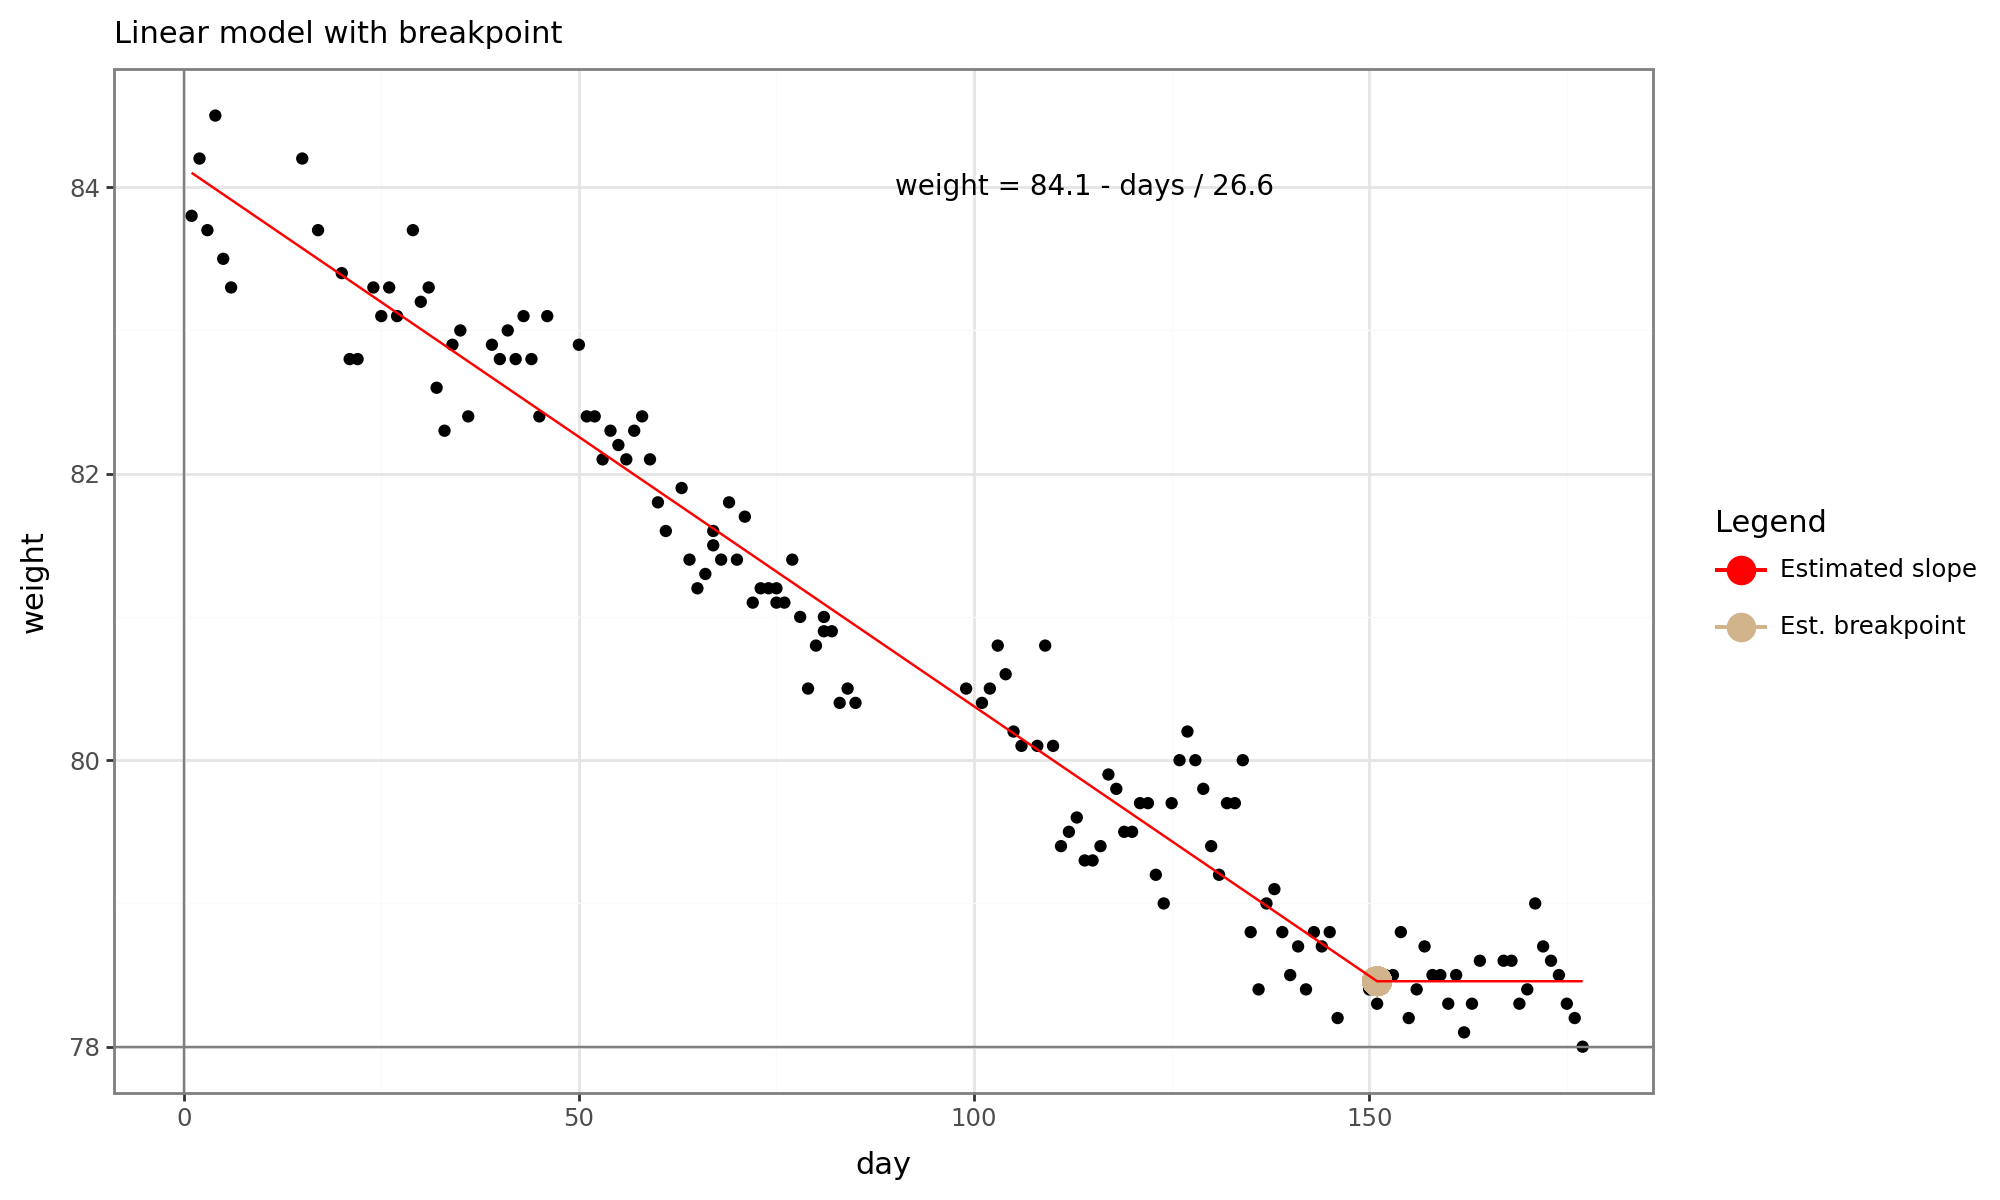

In [18]:
plot = (
    p9.ggplot(data=df)
    + p9.geom_point(mapping=p9.aes(x="x", y="y"))
    + p9.geom_vline(mapping=p9.aes(xintercept=0), color="gray")
    + p9.geom_hline(
        mapping=p9.aes(yintercept=78),
        color="gray",
    )
    + p9.geom_point(
        mapping=p9.aes(
            x=a3,
            y=a4,
            color='"tan"',
        ),
        size=5,
    )
    + p9.theme_bw()
    + p9.geom_line(
        mapping=p9.aes(x="x", y="y_est", color='"red"'),
    )
    + p9.scale_color_identity(
        name="Legend",
        guide="legend",
        breaks=["red", "tan"],
        labels=["Estimated slope", "Est. breakpoint"],
    )
    + p9.labs(
        x="day",
        y="weight",
        subtitle="Linear model with breakpoint",
    )
    + p9.annotate(
        "text",
        x=90,
        y=84,
        label=equation,
        size=10,
        ha="left",
    )
    + p9.theme(figure_size=(10, 6))
)
plot

------------------------

## Conclusions

Visually, the second model is more compelling.  However, it would be a little galling (even if true) to say that my achieving my target was only due to random negative noise cutting in.  If you look very carefully, the last week was a sprint to the finish line, with a consistent linear trend to get to 78kg before the Christmas feasting began!

Overall, I learnt that while it is easy to fit a linear model and say "all done" after you check the R^2 value, it is also moderately easy to use and fit more realistic models

### Model checking

This section just checks that indeed the linear model with breakpoint has a smaller sum-of-errors-squared value than a pure linear model.

Define my sum-of-errors-squared function for the pure linear model

In [19]:
def my_sq_error_linear(a):
    """
    my_sq_error: compute sum of square errors, model vs data

    Parameters: a - an array of model parameters

    We expect a to be an array 2 long, and we interpret the parameters as:
    a1 - initial slope (weight loss per day)
    a2 - initial weight

    For each x value, we compute the model prediction, and square the error with
    the measured value.
    Finally, we sum all square error values

    We expect this function to be called by the function minimization utility
    """
    a1 = a[0]
    a2 = a[1]

    sq_error = []
    for x_i, y_i in zip(x, y):
        y_est = a1 * x_i + a2
        sq_error.append((y_est - y_i) ** 2)
    # end for
    return sum(sq_error)


# end my_sq_error_linear

Find the parameter set the minimizes this function

In [20]:
bounds = [
    slope_range,
    yintercept_range,
]
result2 = scipy.optimize.differential_evolution(
    my_sq_error_linear,
    bounds=bounds,
)

Display the values for each model: Linear Model with Breakpoint wins!

In [21]:
print(f"Sum of errors squared (Pure Linear Model)            = {result2['fun']:.4}")
print(f"Sum of errors squared (Linear Model with breakpoint) = {result1['fun']:.4}")

Sum of errors squared (Pure Linear Model)            = 20.87
Sum of errors squared (Linear Model with breakpoint) = 16.32


Finally, check that the Ordinary Least Square result from __statsmodels__  (OLS) gives the same results as our function minimization of the pure linear model (FunMin):  it does!

In [22]:
print(
    f" Intercept          : OLS={res1.params['Intercept']:.4}  vs FunMin = { result2['x'][1]:.4}\n"
    + f" Slope (days per kg): OLS={1/res1.params['day']:.4} vs FunMin = {1/result2['x'][0]:.4}"
)

 Intercept          : OLS=83.98  vs FunMin = 83.98
 Slope (days per kg): OLS=-28.51 vs FunMin = -28.51


----------------------------------

## Reproducability information

In [23]:
%watermark

Last updated: 2026-02-12T13:52:43.708230+10:00

Python implementation: CPython
Python version       : 3.11.14
IPython version      : 9.10.0

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 170 Stepping 4, GenuineIntel
CPU cores   : 22
Architecture: 64bit



In [24]:
%watermark -h -iv -co

conda environment: fun_minim

Hostname: INSPIRON16

numpy      : 2.4.1
pandas     : 2.3.3
plotnine   : 0.15.0
scipy      : 1.16.3
statsmodels: 0.14.6



In [25]:
import contextlib

import ipynbname

with contextlib.suppress(FileNotFoundError):
    print(f"Notebook file name: {ipynbname.name()}")
# end with

Notebook file name: demo04
